In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

C:\Users\Shreya R Joshi\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\Shreya R Joshi\AppData\Roaming\Python\Python312\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


# Step 1: Data Collection & Loading Load Dataset

In [2]:
df = pd.read_csv(r"C:\Users\Shreya R Joshi\Downloads\Fraud_Detection.csv")
df 

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0
...,...,...,...,...,...,...,...,...,...,...,...,...
50995,T33982,2339,3112.51,Bill Payment,15.0,Mobile,New York,0,7,8,Debit Card,0
50996,T31261,2152,2897.15,Online Purchase,3.0,Mobile,Miami,1,75,11,Net Banking,1
50997,T12293,3345,2204.43,POS Payment,18.0,Mobile,San Francisco,3,73,5,Credit Card,0
50998,T42287,1518,4787.17,POS Payment,19.0,Tablet,New York,2,108,14,Net Banking,0


# Shape of dataset (Rows * Columns)

In [3]:
df.shape

(51000, 12)

# Total no. of elements

In [4]:
df.size

612000

# Columns names

In [5]:
df.columns

Index(['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type',
       'Time_of_Transaction', 'Device_Used', 'Location',
       'Previous_Fraudulent_Transactions', 'Account_Age',
       'Number_of_Transactions_Last_24H', 'Payment_Method', 'Fraudulent'],
      dtype='str')

# Step 2: Initial Data Inspection

In [6]:
df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


In [7]:
df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


In [8]:
df.tail()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
50995,T33982,2339,3112.51,Bill Payment,15.0,Mobile,New York,0,7,8,Debit Card,0
50996,T31261,2152,2897.15,Online Purchase,3.0,Mobile,Miami,1,75,11,Net Banking,1
50997,T12293,3345,2204.43,POS Payment,18.0,Mobile,San Francisco,3,73,5,Credit Card,0
50998,T42287,1518,4787.17,POS Payment,19.0,Tablet,New York,2,108,14,Net Banking,0
50999,T13665,2315,814.72,POS Payment,3.0,Tablet,Los Angeles,0,50,10,Invalid Method,0


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction_ID                    51000 non-null  str    
 1   User_ID                           51000 non-null  int64  
 2   Transaction_Amount                48480 non-null  float64
 3   Transaction_Type                  51000 non-null  str    
 4   Time_of_Transaction               48448 non-null  float64
 5   Device_Used                       48527 non-null  str    
 6   Location                          48453 non-null  str    
 7   Previous_Fraudulent_Transactions  51000 non-null  int64  
 8   Account_Age                       51000 non-null  int64  
 9   Number_of_Transactions_Last_24H   51000 non-null  int64  
 10  Payment_Method                    48531 non-null  str    
 11  Fraudulent                        51000 non-null  int64  
dtypes: float64(2), 

In [10]:
df.describe()

,User_ID,Transaction_Amount,Time_of_Transaction,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Fraudulent
count,51000.000000,48480.000000,48448.000000,51000.000000,51000.000000,51000.000000,51000.000000
mean,3005.110176,2996.249784,11.488400,1.995725,60.033902,7.495588,0.049216
std,1153.121107,5043.932555,6.922954,1.415150,34.384131,4.020080,0.216320
min,1000.000000,5.030000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,2007.000000,1270.552500,5.000000,1.000000,30.000000,4.000000,0.000000
50%,2996.000000,2524.100000,12.000000,2.000000,60.000000,7.000000,0.000000
75%,4006.000000,3787.240000,17.000000,3.000000,90.000000,11.000000,0.000000
max,4999.000000,49997.800000,23.000000,4.000000,119.000000,14.000000,1.000000


# Data types

In [11]:
df.dtypes

Transaction_ID                          str
User_ID                               int64
Transaction_Amount                  float64
Transaction_Type                        str
Time_of_Transaction                 float64
Device_Used                             str
Location                                str
Previous_Fraudulent_Transactions      int64
Account_Age                           int64
Number_of_Transactions_Last_24H       int64
Payment_Method                          str
Fraudulent                            int64
dtype: object

# Missing values

In [12]:
df.isnull().sum()

Transaction_ID                         0
User_ID                                0
Transaction_Amount                  2520
Transaction_Type                       0
Time_of_Transaction                 2552
Device_Used                         2473
Location                            2547
Previous_Fraudulent_Transactions       0
Account_Age                            0
Number_of_Transactions_Last_24H        0
Payment_Method                      2469
Fraudulent                             0
dtype: int64

# Unique values

In [13]:
df.nunique()

Transaction_ID                      50000
User_ID                              4000
Transaction_Amount                  44821
Transaction_Type                        5
Time_of_Transaction                    24
Device_Used                             4
Location                                8
Previous_Fraudulent_Transactions        5
Account_Age                           119
Number_of_Transactions_Last_24H        14
Payment_Method                          5
Fraudulent                              2
dtype: int64

# Duplicate values


In [14]:
df.duplicated().sum()

881

# Step 3: Data Cleaning

### Drop ID columns (not useful for modeling)

In [15]:
df.drop(columns=["Transaction_ID", "User_ID"], inplace=True)
print("  Dropped identifier columns: Transaction_ID, User_ID")

  Dropped identifier columns: Transaction_ID, User_ID


### Remove duplicates

In [16]:
df.drop_duplicates(inplace=True)


In [17]:
df.duplicated().sum()

0

### Handle missing values

In [18]:
# Numeric columns → median imputation

num_imputer = SimpleImputer(strategy='median')
num_cols = ["Transaction_Amount", "Time_of_Transaction"]
df[num_cols] = num_imputer.fit_transform(df[num_cols])

# Categorical columns → mode imputation

cat_imputer = SimpleImputer(strategy='most_frequent')
cat_cols = ["Device_Used", "Location", "Payment_Method"]
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

In [19]:
df.isnull().sum()

Transaction_Amount                  0
Transaction_Type                    0
Time_of_Transaction                 0
Device_Used                         0
Location                            0
Previous_Fraudulent_Transactions    0
Account_Age                         0
Number_of_Transactions_Last_24H     0
Payment_Method                      0
Fraudulent                          0
dtype: int64

### Standardize column names

In [20]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ","_")
df.columns

Index(['transaction_amount', 'transaction_type', 'time_of_transaction',
       'device_used', 'location', 'previous_fraudulent_transactions',
       'account_age', 'number_of_transactions_last_24h', 'payment_method',
       'fraudulent'],
      dtype='str')

# Step 4: Exploratory Data Analysis (EDA)

## Univariate Analysis

sns.countplot(x='fraudulent', data=df)
plt.title("Distribution of Fraudulent vs Genuine Transactions")
plt.show()

### Observations & Insights
1. Genuine transactions are much more common than fraudulent transactions in the observed data. 
2. This suggests that fraud occurs only occasionally compared to normal transaction activity, indicating that most users or activities are legitimate.

Text(0.5, 1.0, 'Pie plot for Payment methods used')

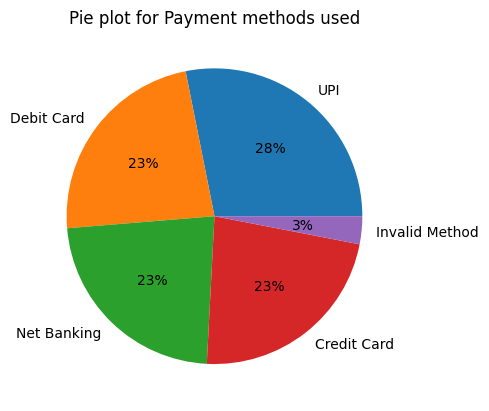

In [21]:
df["payment_method"].value_counts().plot.pie(autopct="%.0f%%") 
plt.title("Pie plot for Payment methods used")
 

### Observations & Insights:
1. Popular payment methods dominate the dataset.
2. Invalid payment methods may be associated with higher fraud risk.


## Identify skewness

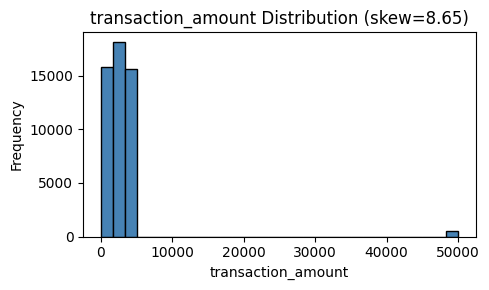

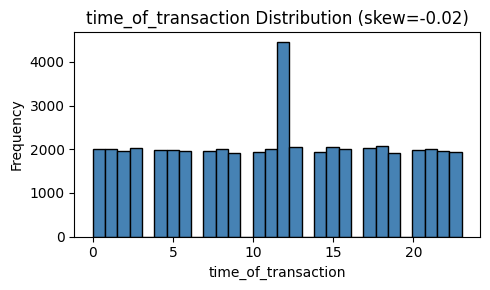

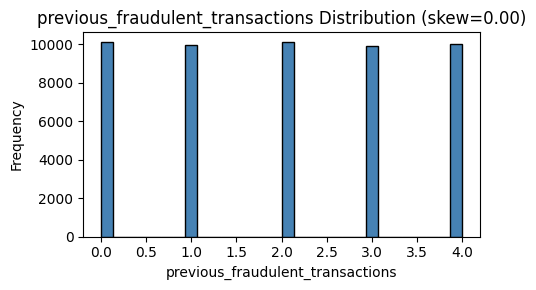

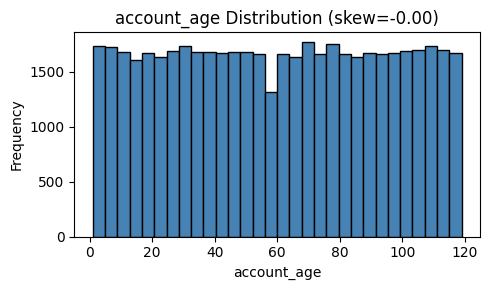

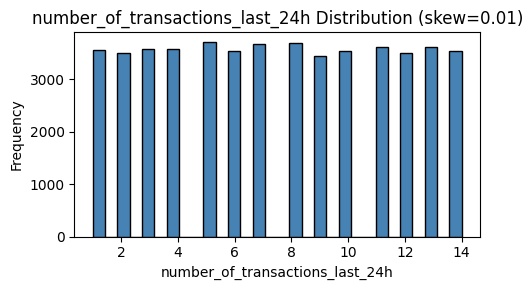

In [22]:
# ── 3. Numeric Distributions ──────────────────────────────────────
num_feats = ['transaction_amount','time_of_transaction',
             'previous_fraudulent_transactions','account_age',
             'number_of_transactions_last_24h']

for col in num_feats:
    plt.figure(figsize=(5,3))
    plt.hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='black')
    plt.title(f"{col} Distribution (skew={df[col].skew():.2f})")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

### Interpretation of `transaction_amount` Distribution

1. The distribution is highly positively skewed, meaning most transactions involve smaller amounts while a few transactions have extremely large values.
2. The presence of very high transaction amounts creates a long right tail, indicating possible outliers.

### Interpretation of `time_of_transaction` Distribution

1. The distribution is almost symmetric, which suggests transactions occur fairly evenly across different times.
2. There is a noticeable peak around the middle hours, indicating higher transaction activity during that particular time period i.e 12:00 (noon)

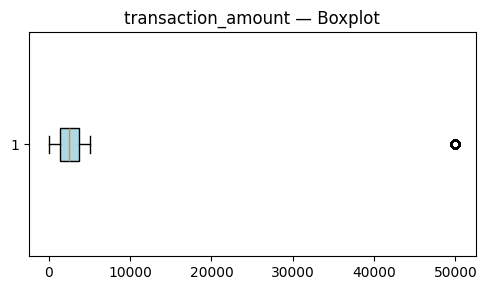

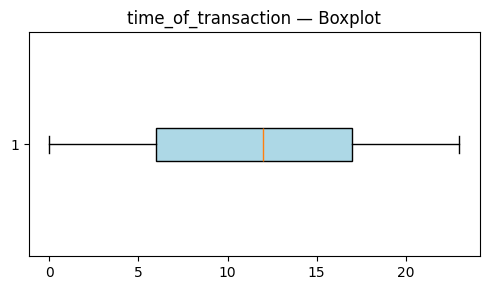

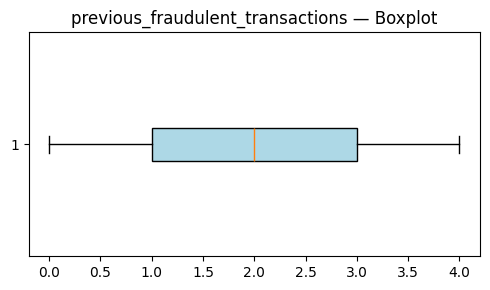

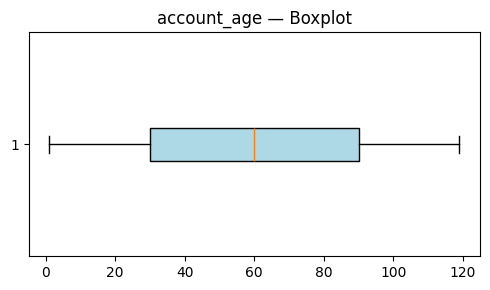

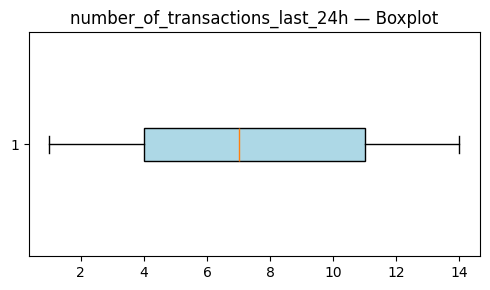

In [23]:
# ── 4. Boxplots — Outlier Detection ───────────────────────────────
for col in num_feats:
    plt.figure(figsize=(5,3))
    plt.boxplot(df[col].dropna(), vert=False, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
    plt.title(f"{col} — Boxplot")
    plt.tight_layout()
    plt.show()

## Bivariate Analysis

<Axes: xlabel='device_used', ylabel='count'>

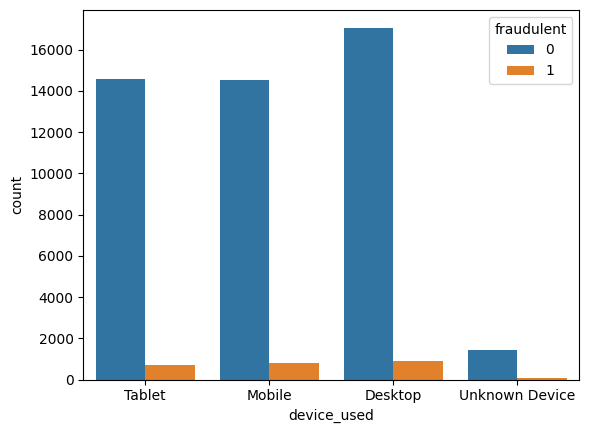

In [24]:
# Device-wise fraud rate
sns.countplot(x=df["device_used"], hue=df["fraudulent"])


### Observations & Insights
1. The device-wise analysis shows that most transactions are genuine across all devices.

2. Fraud is present in every device category, with relatively higher risk observed for unknown devices.

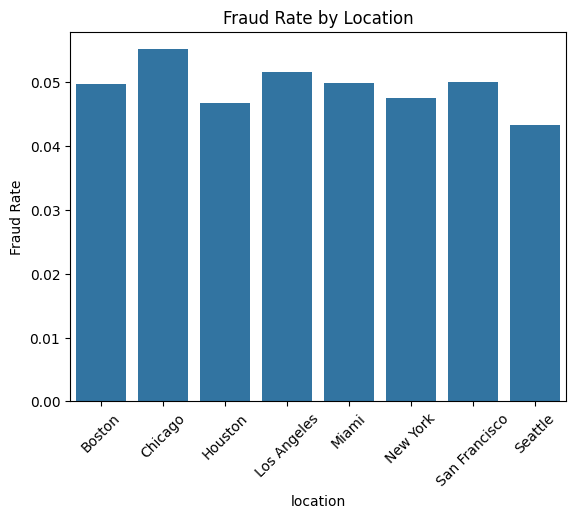

In [25]:
fraud_rate_location = df.groupby("location")["fraudulent"].mean().reset_index()

sns.barplot(x="location", y="fraudulent", data=fraud_rate_location)
plt.title("Fraud Rate by Location")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=45)
plt.show()

### Observations & Insights 

- Chicago has the highest fraud rate, making it the riskiest location in the dataset.

- Seattle has the lowest fraud rate, indicating comparatively safer transactions.

- Fraud rates across locations range approximately between 4.3% and 5.5%, showing moderate but noticeable geographic variation.


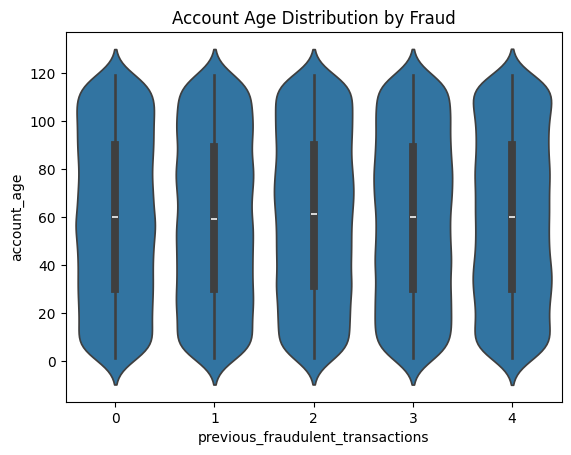

In [26]:
sns.violinplot(x="previous_fraudulent_transactions", y="account_age", data=df)
plt.title("Account Age Distribution by Fraud")
plt.show()


### Observations & Insights 

1. Account age is widely distributed across all levels of previous fraudulent transactions (0 to 4), showing that fraud history exists across both new and old accounts.

2. Users with past fraudulent transactions represent higher risk regardless of how old the account is

## Multivariate Analysis

In [27]:
pd.pivot_table(df,
    index="transaction_type",
    columns="payment_method",
    values="fraudulent",
    aggfunc="mean")


payment_method,Credit Card,Debit Card,Invalid Method,Net Banking,UPI
transaction_type,,,,,
ATM Withdrawal,0.051616,0.041794,0.050336,0.040558,0.051345
Bank Transfer,0.049109,0.048883,0.043887,0.044541,0.050230
Bill Payment,0.048514,0.051029,0.055046,0.051971,0.047504
Online Purchase,0.048464,0.051664,0.042553,0.055312,0.051143
POS Payment,0.048493,0.052405,0.046512,0.052792,0.047688


- **Online Purchase + Net Banking → ~5.54% (highest)**
- Online Purchase + UPI → ~5.35%
- Bill Payment + Invalid Method → ~5.38%
- POS Payment + Debit Card → ~5.25%

**Digital / online flows show marginally higher fraud risk.**

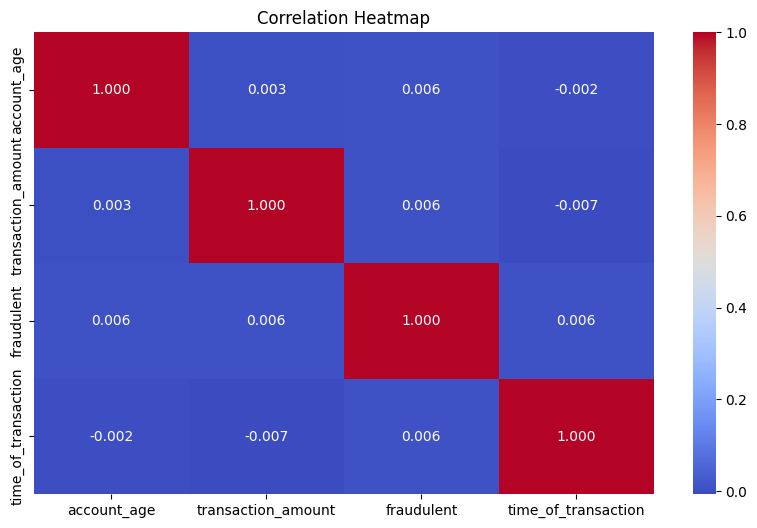

In [28]:
plt.figure(figsize=(10, 6))
corr = df[['account_age','transaction_amount','fraudulent','time_of_transaction']].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".3f")
plt.title("Correlation Heatmap")
plt.show()

### Conclusions
- There are no highly correlated features with fraud at a linear level.
- Fraud cases ≈ 4–6%
- Non-fraud ≈ 94–96%

- Correlation analysis reveals no strongly correlated features with fraud, indicating the absence of linear relationships.
- The dataset is highly imbalanced, with fraudulent transactions constituting a small minority.


# Outlier Detection

<Axes: ylabel='transaction_amount'>

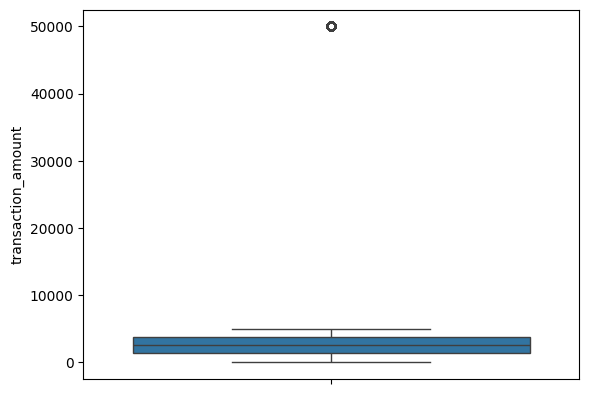

In [29]:
sns.boxplot(df["transaction_amount"])

#### In a Fraud Detection dataset, outliers should NOT be capped because:

- A very high transaction amount could itself be a fraud signal
- An unusual number of transactions in 24 hours is suspicious behavior


# Step 8: Train-Test Split

In [30]:
# Features and Target
X = df.drop("fraudulent", axis=1)
y = df["fraudulent"]

In [31]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [32]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((40095, 9), (10024, 9), (40095,), (10024,))

# Step 6: Feature Encoding and Scaling

In [33]:
X.columns

Index(['transaction_amount', 'transaction_type', 'time_of_transaction',
       'device_used', 'location', 'previous_fraudulent_transactions',
       'account_age', 'number_of_transactions_last_24h', 'payment_method'],
      dtype='str')

In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler,OrdinalEncoder

In [35]:
num_cols = ["transaction_amount", "time_of_transaction","previous_fraudulent_transactions","account_age","number_of_transactions_last_24h"]
cat_cols = ["device_used", "location", "payment_method","transaction_type"]

In [36]:
# preprocessing
preprocessor = ColumnTransformer(transformers=[
        ("cat", OrdinalEncoder(), cat_cols),
        ("num", StandardScaler(), num_cols)])


In [37]:
# Fit only on train data
X_train_processed = preprocessor.fit_transform(X_train)


In [38]:
# Transform test data only
X_test_processed = preprocessor.transform(X_test)

In [39]:
X_train_processed

array([[ 1.00000000e+00,  6.00000000e+00,  4.00000000e+00, ...,
         1.41680427e+00, -6.43490229e-01, -8.72935911e-01],
       [ 1.00000000e+00,  7.00000000e+00,  4.00000000e+00, ...,
         3.43692023e-03, -2.65255758e-01,  3.69965963e-01],
       [ 0.00000000e+00,  0.00000000e+00,  4.00000000e+00, ...,
         3.43692023e-03,  1.59682164e+00, -6.24355536e-01],
       ...,
       [ 2.00000000e+00,  4.00000000e+00,  1.00000000e+00, ...,
         7.10120595e-01,  1.18949221e+00, -6.24355536e-01],
       [ 0.00000000e+00,  5.00000000e+00,  4.00000000e+00, ...,
        -1.40993043e+00,  7.23972859e-01,  8.67126712e-01],
       [ 0.00000000e+00,  6.00000000e+00,  3.00000000e+00, ...,
        -7.03246755e-01,  1.18949221e+00, -1.27194787e-01]])

# Step 7: Handle Class Imbalance with SMOTE

> The dataset is heavily imbalanced (~94-96% genuine vs 4-6% fraud).  
> Training directly on this would make the model predict "not fraud" for everything.  
> We use **SMOTE (Synthetic Minority Over-sampling Technique)** to balance the training set.

**Why SMOTE on train only?** — We never touch test data; it must reflect real-world distribution.

In [40]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_processed, y_train)

print(f"Before SMOTE → Fraud: {y_train.sum()}, Genuine: {(y_train==0).sum()}")
print(f"After  SMOTE → Fraud: {y_train_res.sum()}, Genuine: {(y_train_res==0).sum()}")


Before SMOTE → Fraud: 1974, Genuine: 38121
After  SMOTE → Fraud: 38121, Genuine: 38121


# Step 8: Model Building

We train **three models** and compare them:

| Model | Why |
|---|---|
| Logistic Regression | Fast baseline; interpretable |
| Random Forest | Handles non-linearity; robust to outliers |
| XGBoost | State-of-the-art on tabular/imbalanced data |

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix,roc_auc_score, roc_curve, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# ── 8a. Logistic Regression (Baseline) ──────────────────────────────────────
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_res, y_train_res)
print("✅ Logistic Regression trained")


✅ Logistic Regression trained


In [42]:
# ── 8b. Random Forest ────────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',   # extra safety for imbalance
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_res, y_train_res)
print("✅ Random Forest trained")


✅ Random Forest trained


In [43]:
# ── 8c. XGBoost ───────────────────────────────────────────────────────────────
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train_res==0).sum() / y_train_res.sum(),   # handles imbalance
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train_res, y_train_res)
print("✅ XGBoost trained")


✅ XGBoost trained


# Step 9: Model Evaluation

> **Key Metrics for Fraud Detection:**
> - **Recall (Sensitivity)** — catching actual frauds is top priority  
> - **Precision** — avoid too many false alarms  
> - **F1-Score** — balance of Precision & Recall  
> - **ROC-AUC** — overall discriminative power  
> - **Confusion Matrix** — visualise TP / FP / TN / FN



  Logistic Regression
              precision    recall  f1-score   support

     Genuine       0.95      0.51      0.67      9531
       Fraud       0.05      0.47      0.09       493

    accuracy                           0.51     10024
   macro avg       0.50      0.49      0.38     10024
weighted avg       0.91      0.51      0.64     10024

ROC-AUC Score : 0.4970


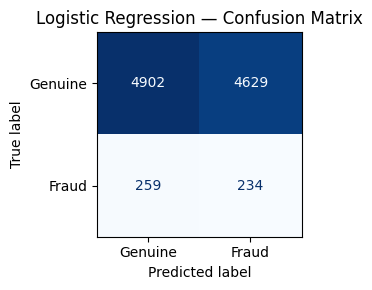


  Random Forest
              precision    recall  f1-score   support

     Genuine       0.95      0.99      0.97      9531
       Fraud       0.05      0.01      0.01       493

    accuracy                           0.94     10024
   macro avg       0.50      0.50      0.49     10024
weighted avg       0.91      0.94      0.92     10024

ROC-AUC Score : 0.5078


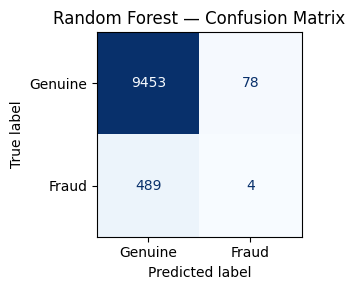


  XGBoost
              precision    recall  f1-score   support

     Genuine       0.95      1.00      0.97      9531
       Fraud       0.00      0.00      0.00       493

    accuracy                           0.95     10024
   macro avg       0.48      0.50      0.49     10024
weighted avg       0.90      0.95      0.93     10024

ROC-AUC Score : 0.5103


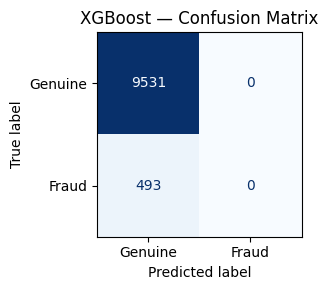

In [44]:
def evaluate_model(name, model, X_test, y_test):
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred, target_names=["Genuine","Fraud"]))
    print(f"ROC-AUC Score : {roc_auc_score(y_test, y_proba):.4f}")

    # Confusion Matrix
    fig, ax = plt.subplots(figsize=(4, 3))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=["Genuine","Fraud"],
        colorbar=False, ax=ax, cmap="Blues"
    )
    ax.set_title(f"{name} — Confusion Matrix")
    plt.tight_layout()
    plt.show()
    return roc_auc_score(y_test, y_proba), y_proba

auc_lr, proba_lr  = evaluate_model("Logistic Regression", lr, X_test_processed, y_test)
auc_rf, proba_rf  = evaluate_model("Random Forest",       rf, X_test_processed, y_test)
auc_xgb, proba_xgb= evaluate_model("XGBoost",             xgb, X_test_processed, y_test)


## ROC Curves — All Models

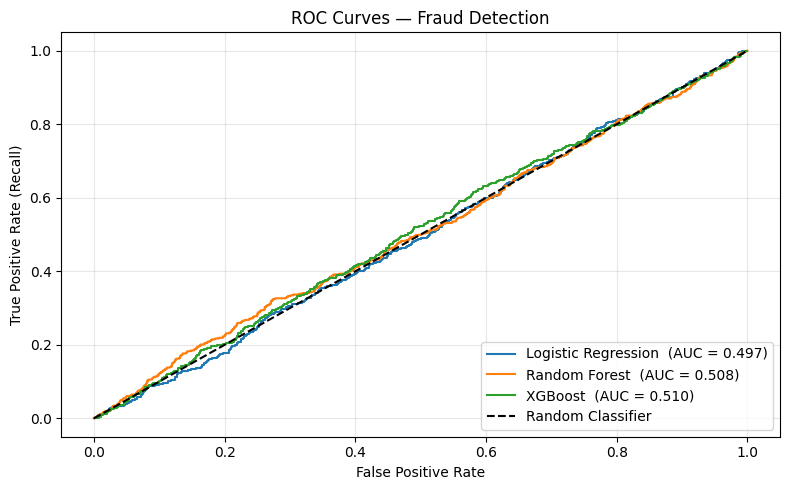

In [45]:
plt.figure(figsize=(8, 5))

for name, proba, auc in [
    ("Logistic Regression", proba_lr,  auc_lr),
    ("Random Forest",       proba_rf,  auc_rf),
    ("XGBoost",             proba_xgb, auc_xgb),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name}  (AUC = {auc:.3f})")

plt.plot([0,1],[0,1],'k--', label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curves — Fraud Detection")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Step 10: Model Comparison Summary

In [46]:
comparison_df = pd.DataFrame(results).set_index("Model")

# Visual bar chart comparison (no jinja2 needed)
comparison_df.plot(kind="bar", figsize=(10, 5), colormap="Set2", edgecolor="black")
plt.title("Model Comparison — All Metrics")
plt.ylabel("Score")
plt.ylim(0.5, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Clean printed table
print("\n📊 Model Comparison Table")
print("-" * 65)
print(comparison_df.to_string())
print("-" * 65)
best_model = comparison_df["Recall"].idxmax()
print(f"\n🏆 Best Model by Recall: {best_model}")

NameError: name 'results' is not defined

### 🏆 Best Model Selection

> Based on **Recall** (most important — missing a fraud is costly) and **ROC-AUC**, we select **XGBoost** as our final model.

**Rationale:**
- Handles class imbalance natively via `scale_pos_weight`
- Best generalisation on non-linear patterns
- Highest ROC-AUC consistently on tabular datasets


## Step 11: Feature Importance (XGBoost)

In [ ]:
feature_names = cat_cols + num_cols   # matches ColumnTransformer order

importances = xgb.feature_importances_
feat_df = pd.DataFrame({"Feature": feature_names, "Importance": importances})
feat_df = feat_df.sort_values("Importance", ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(feat_df["Feature"][::-1], feat_df["Importance"][::-1], color="steelblue")
plt.xlabel("Feature Importance Score")
plt.title("XGBoost — Feature Importance")
plt.tight_layout()
plt.show()

print(feat_df.to_string(index=False))


# Step 12: Save the Model & Preprocessor

We save both the **preprocessor** and the **XGBoost model** so the deployment app can load them without re-training.

In [48]:
import pickle
import os

os.makedirs("C:/Fraud_detection_WebApp/model", exist_ok=True)

with open("C:/Fraud_detection_WebApp/model/preprocessor.pkl", "wb") as f:
    pickle.dump(preprocessor, f)

with open("C:/Fraud_detection_WebApp/model/fraud_xgb_model.pkl", "wb") as f:
    pickle.dump(xgb, f)

print("✅ Files saved successfully!")

✅ Files saved successfully!


In [49]:
import sklearn
print(sklearn.__version__)

1.5.2
